# Proyek Akhir: Sistem Prediksi Risiko Dropout Mahasiswa Jaya Jaya Institut

- Nama: Septa Bagas Setyawan
- Email: septabagas.2023@student.iny.ac.id
- Id Dicoding: CDCC015D6Y2100

## Persiapan

### Menyiapkan library yang dibutuhkan

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score
)

import os

import joblib

import warnings
warnings.filterwarnings("ignore")

pd.set_option('display.max_columns', None)

### Menyiapkan data yang akan diguankan

In [78]:
df = pd.read_csv('/content/data.csv', delimiter=";")

## Data Understanding

In [79]:
df.shape

(4424, 37)

In [80]:
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

In [82]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [83]:
df.isna().sum()

,0
Marital_status,0
Application_mode,0
Application_order,0
Course,0
Daytime_evening_attendance,0
Previous_qualification,0
Previous_qualification_grade,0
Nacionality,0
Mothers_qualification,0
Fathers_qualification,0


In [84]:
print('Data Duplicated :', df.duplicated().sum())

Data Duplicated : 0


In [85]:
status_counts = df["Status"].value_counts()
status_percent = df["Status"].value_counts(normalize=True).mul(100).round(2)

print("Jumlah mahasiswa berdasarkan status:")
print(status_counts)
print("\nPersentase:")
print(status_percent)

Jumlah mahasiswa berdasarkan status:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Persentase:
Status
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


In [86]:
status_counts = df["Status"].value_counts()
status_percent = df["Status"].value_counts(normalize=True).mul(100).round(2)

print("Jumlah mahasiswa berdasarkan status:")
print(status_counts)
print("\nPersentase:")
print(status_percent)

Jumlah mahasiswa berdasarkan status:
Status
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Persentase:
Status
Graduate    49.93
Dropout     32.12
Enrolled    17.95
Name: proportion, dtype: float64


In [87]:
df_model = df[df["Status"].isin(["Dropout", "Graduate"])].copy()
df_enrolled = df[df["Status"] == "Enrolled"].copy()

print("Data untuk modeling:", df_model.shape)
print("Data Enrolled yang dipisahkan:", df_enrolled.shape)

print("\nDistribusi data modeling:")
print(df_model["Status"].value_counts())

print("\nJumlah Enrolled yang tidak digunakan untuk training:", len(df_enrolled))

Data untuk modeling: (3630, 37)
Data Enrolled yang dipisahkan: (794, 37)

Distribusi data modeling:
Status
Graduate    2209
Dropout     1421
Name: count, dtype: int64

Jumlah Enrolled yang tidak digunakan untuk training: 794


## Data Preparation / Preprocessing

### Labeling

In [88]:
df_model["Target"] = (df_model["Status"] == "Dropout").astype(int)

print(df_model[["Status", "Target"]].drop_duplicates().sort_values("Target"))
print("\nDistribusi target:")
print(df_model["Target"].value_counts().sort_index())
print("\nKeterangan: 0 = Graduate, 1 = Dropout")

     Status  Target
1  Graduate       0
0   Dropout       1

Distribusi target:
Target
0    2209
1    1421
Name: count, dtype: int64

Keterangan: 0 = Graduate, 1 = Dropout


In [89]:
Marital_map = {
    1: "Single", 2: "Married", 3: "Widower",
    4: "Divorced", 5: "Facto union", 6: "Legally separated"
}
Gender_map = {0: "Female", 1: "Male"}
Binary_map = {0: "No", 1: "Yes"}
Attendance_map = {0: "Evening", 1: "Daytime"}

Previous_map = {
    1: "Secondary education",
    2: "Higher education - bachelor's degree",
    3: "Higher education - degree",
    4: "Higher education - master's",
    5: "Higher education - doctorate",
    6: "Frequency of higher education",
    9: "12th year of schooling - not completed",
    10: "11th year of schooling - not completed",
    12: "Other - 11th year of schooling",
    14: "10th year of schooling",
    15: "10th year of schooling - not completed",
    19: "Basic education 3rd cycle or equivalent",
    38: "Basic education 2nd cycle or equivalent",
    39: "Technological specialization course",
    40: "Higher education - degree (1st cycle)",
    42: "Professional higher technical course",
    43: "Higher education - master (2nd cycle)"
}

Nacionality_map = {
    1:"Portuguese", 2:"German", 6:"Spanish", 11:"Italian", 13:"Dutch",
    14:"English", 17:"Lithuanian", 21:"Angolan", 22:"Cape Verdean",
    24:"Guinean", 25:"Mozambican", 26:"Santomean", 32:"Turkish",
    41:"Brazilian", 62:"Romanian", 100:"Moldova (Republic of)",
    101:"Mexican", 103:"Ukrainian", 105:"Russian", 108:"Cuban",
    109:"Colombian"
}

df["Marital_status_label"] = df["Marital_status"].map(Marital_map)
df["Gender_label"] = df["Gender"].map(Gender_map)
df["Tuition_fees_up_to_date_label"] = df["Tuition_fees_up_to_date"].map(Binary_map)
df["Displaced_label"] = df["Displaced"].map(Binary_map)
df["Educational_special_needs_label"] = df["Educational_special_needs"].map(Binary_map)
df["Scholarship_holder_label"] = df["Scholarship_holder"].map(Binary_map)
df["Debtor_label"] = df["Debtor"].map(Binary_map)
df["Daytime_evening_attendance_label"] = df["Daytime_evening_attendance"].map(Attendance_map)
df["International_label"] = df["International"].map(Binary_map)
df["Previous_qualification_label"] = df["Previous_qualification"].map(Previous_map)

# Bentuk ulang subset setelah penambahan label
df_model = df[df["Status"].isin(["Dropout", "Graduate"])].copy()
df_enrolled = df[df["Status"] == "Enrolled"].copy()
df_model["Target"] = (df_model["Status"] == "Dropout").astype(int)

df_model.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,Mothers_occupation,Fathers_occupation,Admission_grade,Displaced,Educational_special_needs,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,International,Curricular_units_1st_sem_credited,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_evaluations,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_1st_sem_without_evaluations,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status,Marital_status_label,Gender_label,Tuition_fees_up_to_date_label,Displaced_label,Educational_special_needs_label,Scholarship_holder_label,Debtor_label,Daytime_evening_attendance_label,International_label,Previous_qualification_label,Target
0,1,17,5,171,1,1,122.0,1,19,12,5,9,127.3,1,0,0,1,1,0,20,0,0,0,0,0,0.000000,0,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout,Single,Male,Yes,Yes,No,No,No,Daytime,No,Secondary education,1
1,1,15,1,9254,1,1,160.0,1,1,3,3,3,142.5,1,0,0,0,1,0,19,0,0,6,6,6,14.000000,0,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate,Single,Male,No,Yes,No,No,No,Daytime,No,Secondary education,0
2,1,1,5,9070,1,1,122.0,1,37,37,9,9,124.8,1,0,0,0,1,0,19,0,0,6,0,0,0.000000,0,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout,Single,Male,No,Yes,No,No,No,Daytime,No,Secondary education,1
3,1,17,2,9773,1,1,122.0,1,38,37,5,3,119.6,1,0,0,1,0,0,20,0,0,6,8,6,13.428571,0,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate,Single,Female,Yes,Yes,No,No,No,Daytime,No,Secondary education,0
4,2,39,1,8014,0,1,100.0,1,37,38,9,9,141.5,0,0,0,1,0,0,45,0,0,6,9,5,12.333333,0,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate,Married,Female,Yes,No,No,No,No,Evening,No,Secondary education,0


### Exploratory Data Analysis (EDA)

#### Distribusi Target

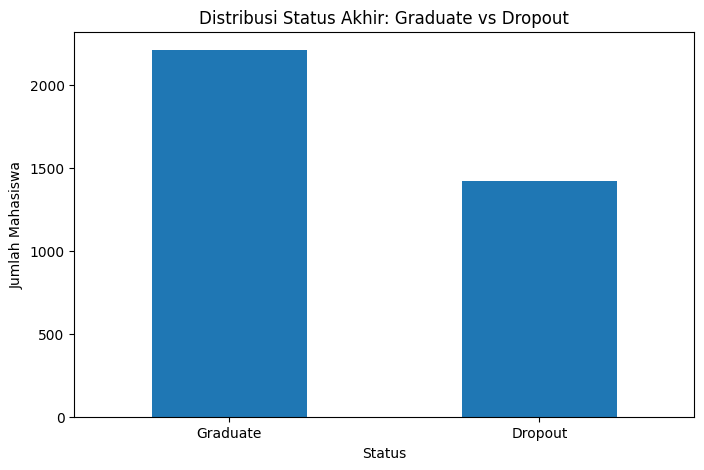

In [90]:
status_counts_model = df_model["Status"].value_counts().reindex(["Graduate", "Dropout"])

plt.figure(figsize=(8, 5))
status_counts_model.plot(kind="bar")
plt.title("Distribusi Status Akhir: Graduate vs Dropout")
plt.xlabel("Status")
plt.ylabel("Jumlah Mahasiswa")
plt.xticks(rotation=0)
plt.show()

#### Usia saat Pendaftaran vs Status

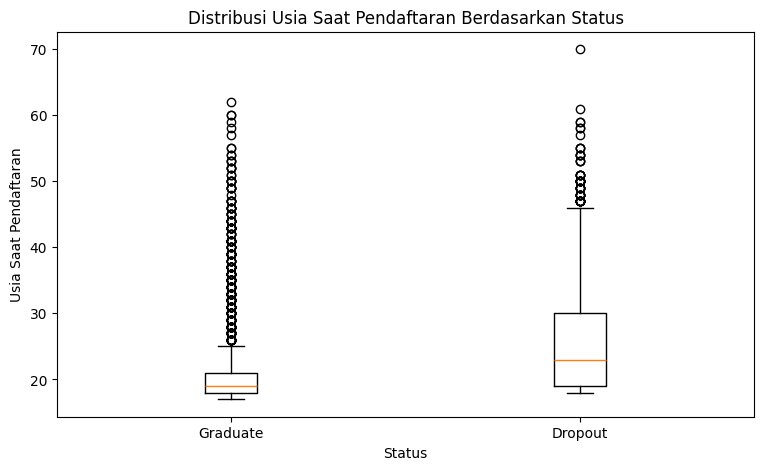

Status
Graduate    21.78
Dropout     26.07
Name: Age_at_enrollment, dtype: float64


In [91]:
groups = [
    df_model.loc[df_model["Status"] == "Graduate", "Age_at_enrollment"].dropna(),
    df_model.loc[df_model["Status"] == "Dropout", "Age_at_enrollment"].dropna()
]

plt.figure(figsize=(9, 5))
plt.boxplot(groups, labels=["Graduate", "Dropout"])
plt.title("Distribusi Usia Saat Pendaftaran Berdasarkan Status")
plt.xlabel("Status")
plt.ylabel("Usia Saat Pendaftaran")
plt.show()

print(
    df_model.groupby("Status")["Age_at_enrollment"]
    .mean()
    .reindex(["Graduate", "Dropout"])
    .round(2)
)

#### Gender vs Status

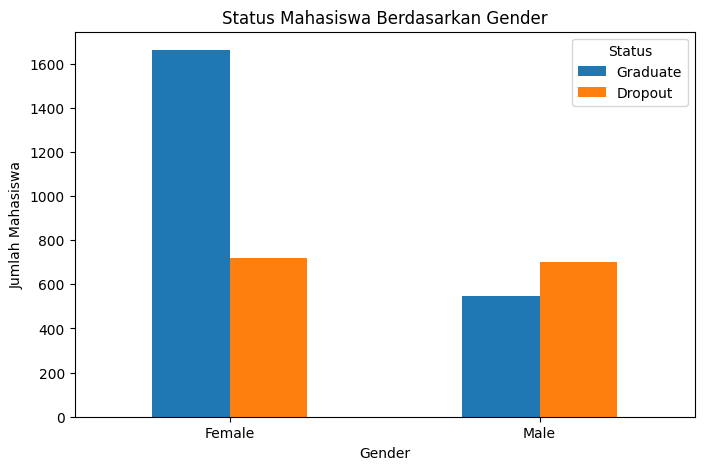

In [92]:
gender_counts = pd.crosstab(df_model["Gender_label"], df_model["Status"]).reindex(
    index=["Female", "Male"], columns=["Graduate", "Dropout"], fill_value=0
)

gender_counts.plot(kind="bar", figsize=(8, 5))
plt.title("Status Mahasiswa Berdasarkan Gender")
plt.xlabel("Gender")
plt.ylabel("Jumlah Mahasiswa")
plt.xticks(rotation=0)
plt.show()

#### Performa Akademik

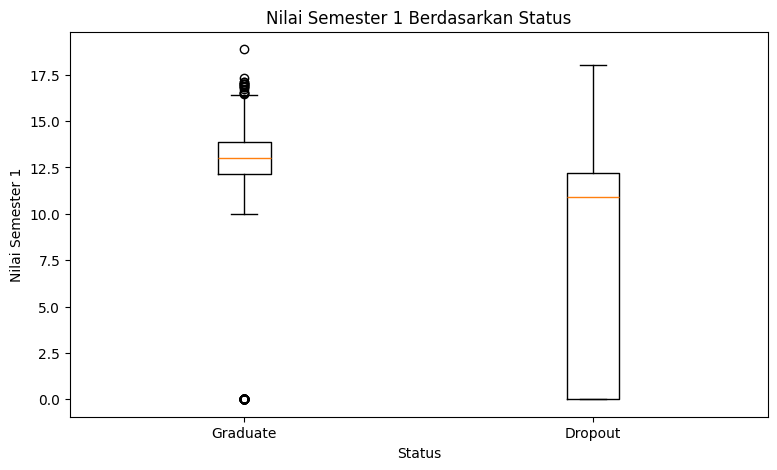

In [93]:
groups = [
    df_model.loc[df_model["Status"] == "Graduate", "Curricular_units_1st_sem_grade"].dropna(),
    df_model.loc[df_model["Status"] == "Dropout", "Curricular_units_1st_sem_grade"].dropna()
]

plt.figure(figsize=(9, 5))
plt.boxplot(groups, labels=["Graduate", "Dropout"])
plt.title("Nilai Semester 1 Berdasarkan Status")
plt.xlabel("Status")
plt.ylabel("Nilai Semester 1")
plt.show()

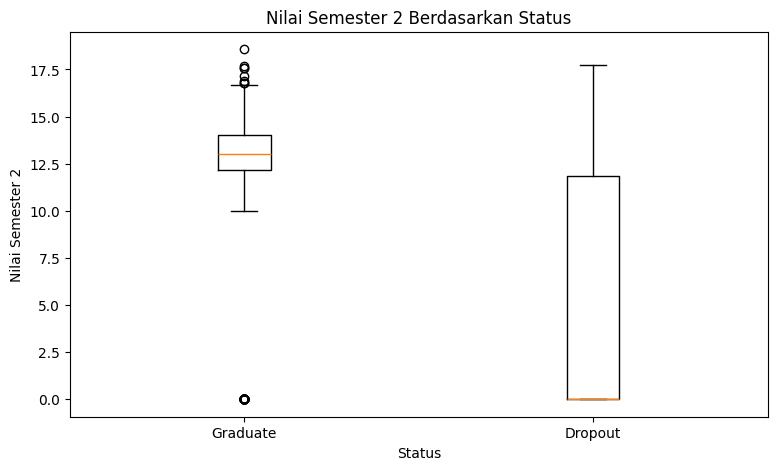

In [94]:
groups = [
    df_model.loc[df_model["Status"] == "Graduate", "Curricular_units_2nd_sem_grade"].dropna(),
    df_model.loc[df_model["Status"] == "Dropout", "Curricular_units_2nd_sem_grade"].dropna()
]

plt.figure(figsize=(9, 5))
plt.boxplot(groups, labels=["Graduate", "Dropout"])
plt.title("Nilai Semester 2 Berdasarkan Status")
plt.xlabel("Status")
plt.ylabel("Nilai Semester 2")
plt.show()

#### Jumlah Mata Kuliah yang Disetujui

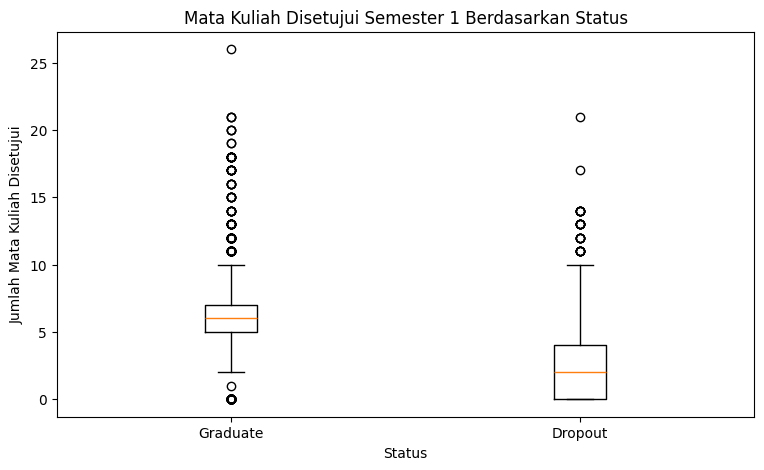

In [95]:
groups = [
    df_model.loc[df_model["Status"] == "Graduate", "Curricular_units_1st_sem_approved"].dropna(),
    df_model.loc[df_model["Status"] == "Dropout", "Curricular_units_1st_sem_approved"].dropna()
]

plt.figure(figsize=(9, 5))
plt.boxplot(groups, labels=["Graduate", "Dropout"])
plt.title("Mata Kuliah Disetujui Semester 1 Berdasarkan Status")
plt.xlabel("Status")
plt.ylabel("Jumlah Mata Kuliah Disetujui")
plt.show()

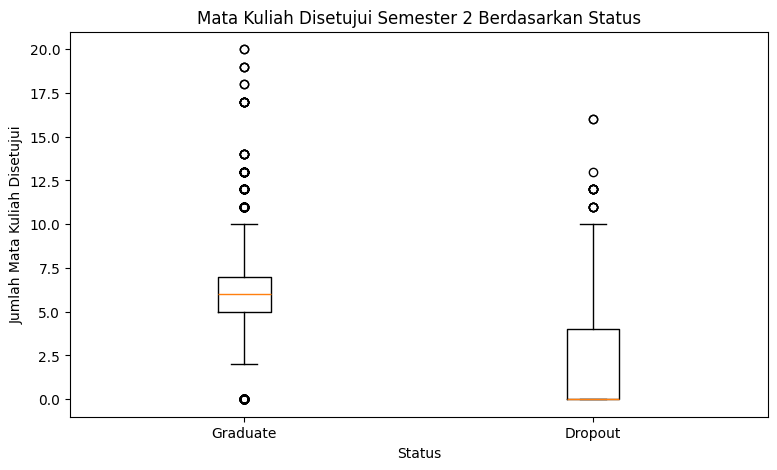

In [96]:
groups = [
    df_model.loc[df_model["Status"] == "Graduate", "Curricular_units_2nd_sem_approved"].dropna(),
    df_model.loc[df_model["Status"] == "Dropout", "Curricular_units_2nd_sem_approved"].dropna()
]

plt.figure(figsize=(9, 5))
plt.boxplot(groups, labels=["Graduate", "Dropout"])
plt.title("Mata Kuliah Disetujui Semester 2 Berdasarkan Status")
plt.xlabel("Status")
plt.ylabel("Jumlah Mata Kuliah Disetujui")
plt.show()

#### Faktor Finansial

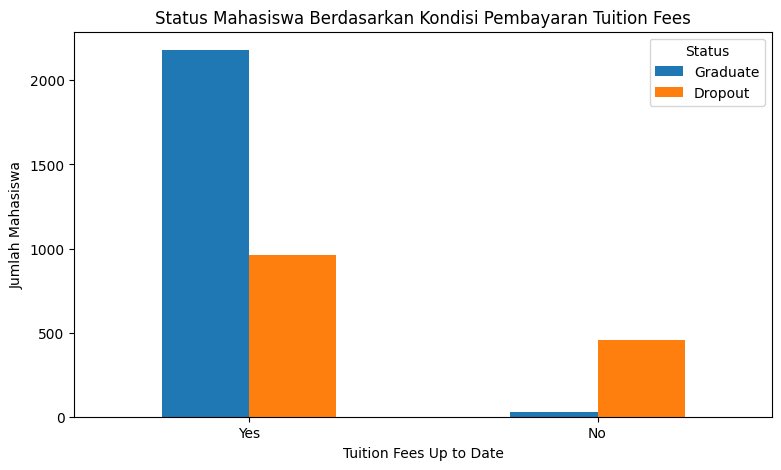

In [97]:
tuition_counts = pd.crosstab(
    df_model["Tuition_fees_up_to_date_label"],
    df_model["Status"]
).reindex(index=["Yes", "No"], columns=["Graduate", "Dropout"], fill_value=0)

tuition_counts.plot(kind="bar", figsize=(9, 5))
plt.title("Status Mahasiswa Berdasarkan Kondisi Pembayaran Tuition Fees")
plt.xlabel("Tuition Fees Up to Date")
plt.ylabel("Jumlah Mahasiswa")
plt.xticks(rotation=0)
plt.show()

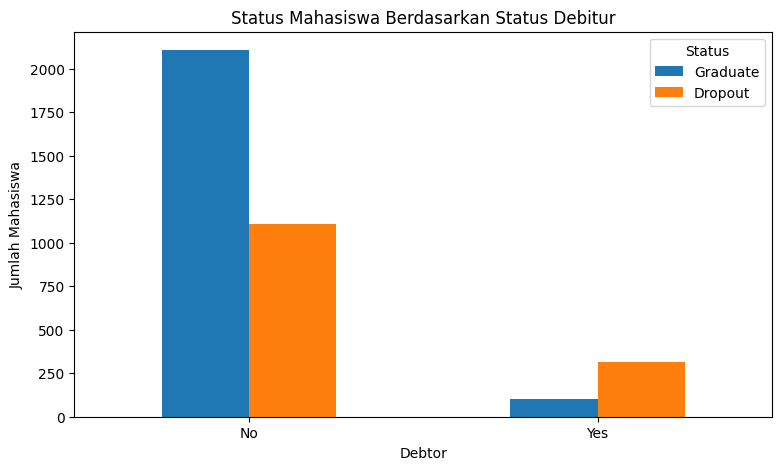

In [98]:
debtor_counts = pd.crosstab(
    df_model["Debtor_label"],
    df_model["Status"]
).reindex(index=["No", "Yes"], columns=["Graduate", "Dropout"], fill_value=0)

debtor_counts.plot(kind="bar", figsize=(9, 5))
plt.title("Status Mahasiswa Berdasarkan Status Debitur")
plt.xlabel("Debtor")
plt.ylabel("Jumlah Mahasiswa")
plt.xticks(rotation=0)
plt.show()

#### Korelasi Fitur Numerik

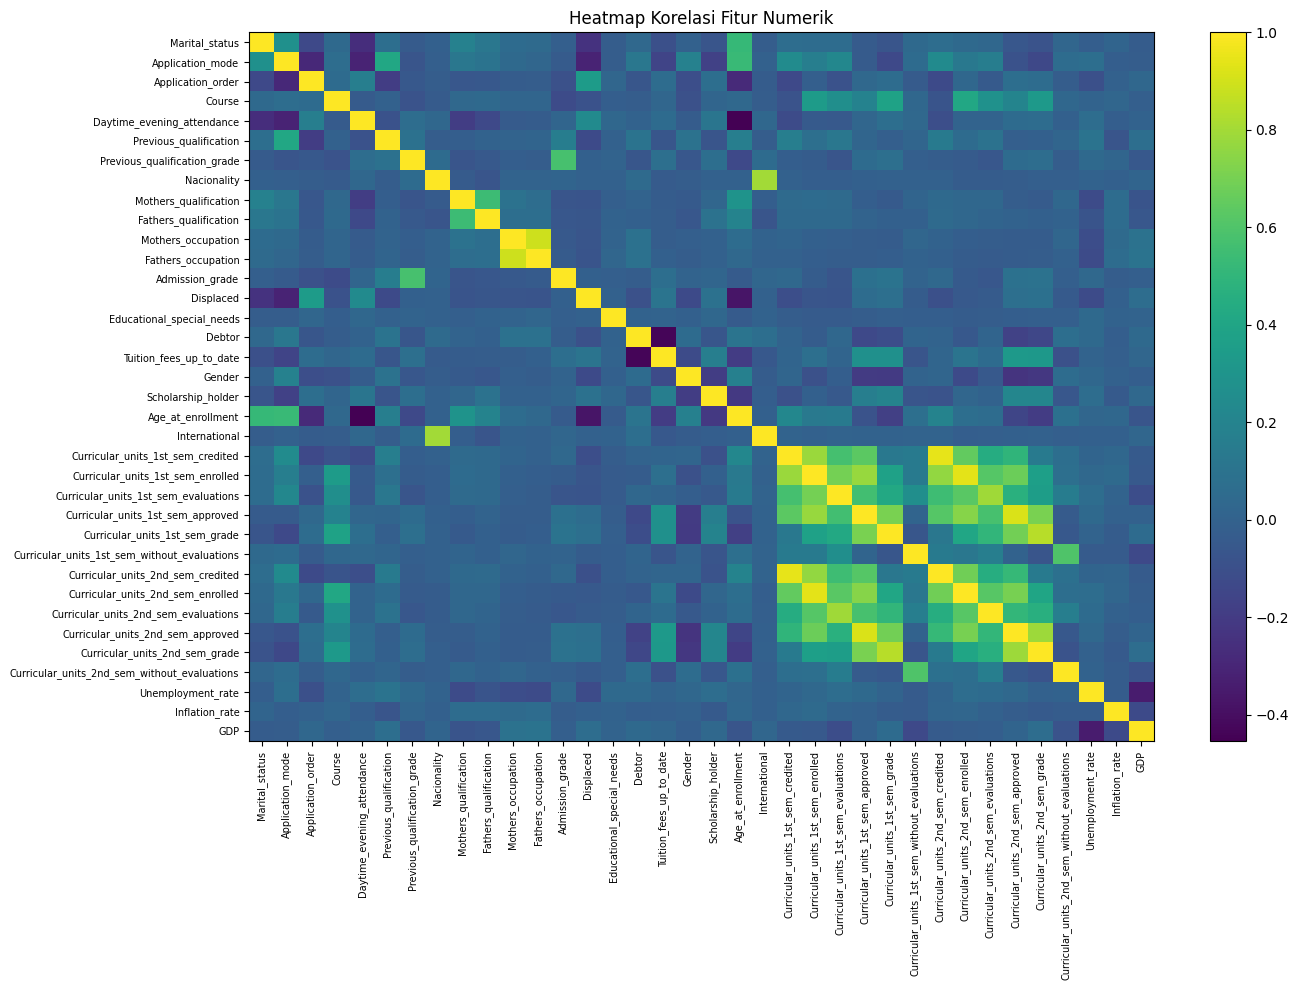

In [99]:
numeric_for_corr = df_model.select_dtypes(include=np.number).drop(
    columns=["Target"], errors="ignore"
)
corr = numeric_for_corr.corr()

fig, ax = plt.subplots(figsize=(14, 10))
im = ax.imshow(corr, aspect="auto")
ax.set_xticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticks(range(len(corr.index)))
ax.set_yticklabels(corr.index, fontsize=7)
ax.set_title("Heatmap Korelasi Fitur Numerik")
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## Modeling

### Feature & Target

In [100]:
label_columns = [col for col in df_model.columns if col.endswith("_label")]

X = df_model.drop(columns=["Status", "Target"] + label_columns)
y = df_model["Target"]

print("Shape X:", X.shape)
print("Shape y:", y.shape)
print("\nDistribusi target:")
print(y.value_counts().sort_index())
print("\n0 = Graduate | 1 = Dropout")

Shape X: (3630, 36)
Shape y: (3630,)

Distribusi target:
Target
0    2209
1    1421
Name: count, dtype: int64

0 = Graduate | 1 = Dropout


### Train-Test Split

In [101]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data training:", X_train.shape)
print("Data testing :", X_test.shape)

Data training: (2904, 36)
Data testing : (726, 36)


### Preprocessing Pipeline

In [102]:
categorical_columns = [
    "Marital_status",
    "Application_mode",
    "Course",
    "Daytime_evening_attendance",
    "Previous_qualification",
    "Nacionality",
    "Mothers_qualification",
    "Fathers_qualification",
    "Mothers_occupation",
    "Fathers_occupation",
    "Displaced",
    "Educational_special_needs",
    "Debtor",
    "Tuition_fees_up_to_date",
    "Gender",
    "Scholarship_holder",
    "International"
]

numerical_columns = [
    col for col in X.columns
    if col not in categorical_columns
]

print("Jumlah fitur kategorikal:", len(categorical_columns))
print("Jumlah fitur numerik:", len(numerical_columns))

Jumlah fitur kategorikal: 17
Jumlah fitur numerik: 19


In [103]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

### Random Forest Classifier

In [104]:
model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

model_pipeline.fit(X_train, y_train)
print("Model berhasil dilatih.")

Model berhasil dilatih.


## Evaluation

In [105]:
y_pred = model_pipeline.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.9284
Precision: 0.9361
Recall   : 0.8768
F1-Score : 0.9055


In [106]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Graduate", "Dropout"],
        digits=4
    )
)

              precision    recall  f1-score   support

    Graduate     0.9239    0.9615    0.9424       442
     Dropout     0.9361    0.8768    0.9055       284

    accuracy                         0.9284       726
   macro avg     0.9300    0.9191    0.9239       726
weighted avg     0.9287    0.9284    0.9279       726



### Confusion Matrix

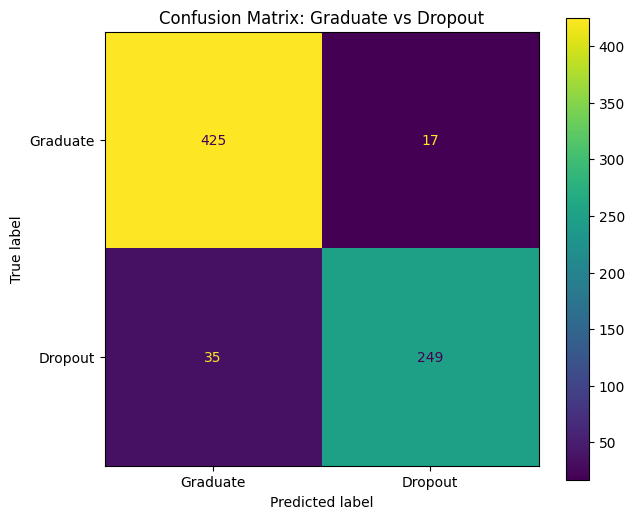

In [107]:
labels = [0, 1]
display_labels = ["Graduate", "Dropout"]

cm = confusion_matrix(y_test, y_pred, labels=labels)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
)

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, values_format="d")
plt.title("Confusion Matrix: Graduate vs Dropout")
plt.show()

## Analisis Feature Importance

In [108]:
feature_names = model_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = model_pipeline.named_steps["model"].feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    })
    .sort_values("Importance", ascending=False)
)

display(feature_importance.head(20))

,Feature,Importance
13,num__Curricular_units_2nd_sem_approved,0.147788
14,num__Curricular_units_2nd_sem_grade,0.111742
7,num__Curricular_units_1st_sem_approved,0.097670
8,num__Curricular_units_1st_sem_grade,0.066452
12,num__Curricular_units_2nd_sem_evaluations,0.034749
228,cat__Tuition_fees_up_to_date_1,0.032069
227,cat__Tuition_fees_up_to_date_0,0.030442
6,num__Curricular_units_1st_sem_evaluations,0.028292
3,num__Age_at_enrollment,0.027168
2,num__Admission_grade,0.025382


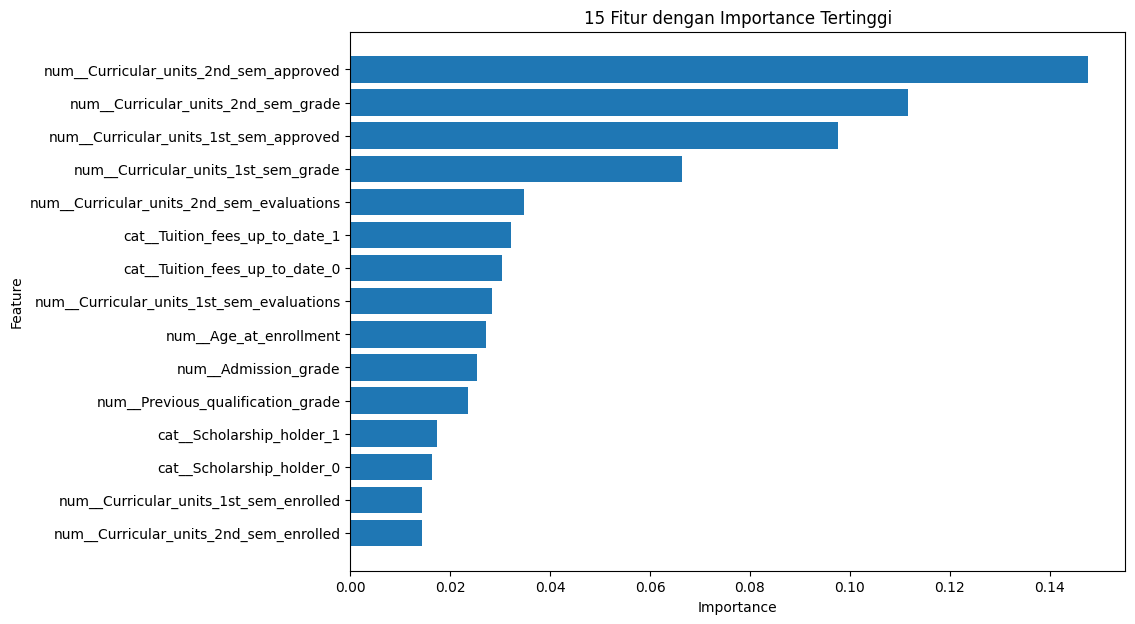

In [109]:
top_features = feature_importance.head(15).sort_values("Importance")

plt.figure(figsize=(10, 7))
plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)
plt.title("15 Fitur dengan Importance Tertinggi")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [110]:
summary_characteristics = df_model.groupby("Status").agg({
    "Age_at_enrollment": "mean",
    "Curricular_units_1st_sem_approved": "mean",
    "Curricular_units_1st_sem_grade": "mean",
    "Curricular_units_2nd_sem_approved": "mean",
    "Curricular_units_2nd_sem_grade": "mean"
}).reindex(["Graduate", "Dropout"]).round(2)

display(summary_characteristics)

,Age_at_enrollment,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade
Status,,,,,
Graduate,21.78,6.23,12.64,6.18,12.7
Dropout,26.07,2.55,7.26,1.94,5.9


## Simpan Model

In [111]:
os.makedirs("model", exist_ok=True)

model_path = "model/dropout_prediction_pipeline.pkl"

joblib.dump(
    model_pipeline,
    model_path
)

print(f"Model berhasil disimpan di: {model_path}")

Model berhasil disimpan di: model/dropout_prediction_pipeline.pkl


In [112]:
loaded_model = joblib.load(model_path)
test_prediction = loaded_model.predict(X_test.iloc[:5])

print("Model berhasil dimuat kembali.")
print("Contoh prediksi:", test_prediction)
print("0 = Graduate | 1 = Dropout")

Model berhasil dimuat kembali.
Contoh prediksi: [0 0 0 0 1]
0 = Graduate | 1 = Dropout


In [113]:
os.makedirs("data", exist_ok=True)

enrolled_path = "data/enrolled_for_future_prediction.csv"

df_enrolled.to_csv(
    enrolled_path,
    index=False
)

print(f"Data Enrolled berhasil disimpan di: {enrolled_path}")
print("Jumlah data Enrolled:", len(df_enrolled))

Data Enrolled berhasil disimpan di: data/enrolled_for_future_prediction.csv
Jumlah data Enrolled: 794


### Menyiapkan Data Dashboard

In [ ]:
dashboard_df = df.copy()

# Tambahkan beberapa label numerik yang umum dipakai dashboard
dashboard_df["Status"] = dashboard_df["Status"].astype(str)
dashboard_df["Age_group"] = pd.cut(
    dashboard_df["Age_at_enrollment"],
    bins=[0, 20, 25, 30, 100],
    labels=["<=20", "21-25", "26-30", ">30"],
    include_lowest=True
)

dashboard_path = "data/dashboard_data.csv"
dashboard_df.to_csv(dashboard_path, index=False)

print(f"Dashboard data berhasil disimpan di: {dashboard_path}")
print("Shape:", dashboard_df.shape)
print("Status:", dashboard_df["Status"].value_counts().to_dict())

## Kesimpulan

Model berhasil dibangun sebagai **binary classification** untuk membedakan mahasiswa `Dropout` dan `Graduate`. Mahasiswa `Enrolled` tidak dilibatkan dalam training karena belum memiliki label akhir, dan disimpan terpisah untuk penggunaan prediksi di masa mendatang.

Model ini dapat menjadi prototype untuk membantu institusi melakukan identifikasi risiko berdasarkan karakteristik historis mahasiswa. Hasil model perlu digunakan sebagai alat bantu pengambilan keputusan dan tetap dikombinasikan dengan evaluasi dari pihak akademik.